In [14]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns  
%pip install scipy
%pip install dataframe as df
from scipy.stats import linregress

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement dataframe (from versions: none)
ERROR: No matching distribution found for dataframe


In [15]:
df_googl = yf.download('GOOGL', start='2023-01-01', end='2026-01-01')
df_sp500 = yf.download('^GSPC', start='2023-01-01', end='2026-01-01')
googl_close = df_googl['Close'].squeeze().rename('GOOGL')
sp500_close = df_sp500['Close'].squeeze().rename('S&P 500')

df = pd.concat([googl_close, sp500_close], axis=1).dropna()
df.head()

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


,GOOGL,S&P 500
Date,,
2023-01-03,88.279953,3824.139893
2023-01-04,87.249756,3852.969971
2023-01-05,85.387474,3808.100098
2023-01-06,86.516731,3895.080078
2023-01-09,87.190315,3892.090088


In [16]:
googl_close = df_googl['Close'].squeeze().rename('GOOGL')
sp500_close = df_sp500['Close'].squeeze().rename('S&P 500')

df = pd.concat([googl_close, sp500_close], axis=1).dropna()
df.head()


,GOOGL,S&P 500
Date,,
2023-01-03,88.279953,3824.139893
2023-01-04,87.249756,3852.969971
2023-01-05,85.387474,3808.100098
2023-01-06,86.516731,3895.080078
2023-01-09,87.190315,3892.090088


In [17]:
returns_df = df.pct_change(1).dropna()
returns_df.head()

,GOOGL,S&P 500
Date,,
2023-01-04,-0.011670,0.007539
2023-01-05,-0.021344,-0.011646
2023-01-06,0.013225,0.022841
2023-01-09,0.007786,-0.000768
2023-01-10,0.004545,0.006978


In [18]:
new_col_name = 'r_googl','r_sp500'
returns_df.columns = new_col_name
returns_df.head()

,r_googl,r_sp500
Date,,
2023-01-04,-0.011670,0.007539
2023-01-05,-0.021344,-0.011646
2023-01-06,0.013225,0.022841
2023-01-09,0.007786,-0.000768
2023-01-10,0.004545,0.006978


In [19]:
deviations = returns_df - returns_df.mean()
deviations.head()


,r_googl,r_sp500
Date,,
2023-01-04,-0.013535,0.006719
2023-01-05,-0.023210,-0.012466
2023-01-06,0.011360,0.022020
2023-01-09,0.005920,-0.001588
2023-01-10,0.002679,0.006158


In [20]:
returns_df ['r_googl'].iloc[0] - returns_df['r_googl'].mean()
#Using I loc to access the first row of the 'r_googl' column and subtracting the mean of that column from it. 
#This gives us the deviation of the first return from the mean return for GOOGL.

np.float64(-0.013535085800035686)

In [21]:
new_col_names = 'deviations_googl','deviations_sp500'
deviations.columns = new_col_names
deviations.head()
#Deviation is the difference between each return and the mean return for that stock/index.

,deviations_googl,deviations_sp500
Date,,
2023-01-04,-0.013535,0.006719
2023-01-05,-0.023210,-0.012466
2023-01-06,0.011360,0.022020
2023-01-09,0.005920,-0.001588
2023-01-10,0.002679,0.006158


In [22]:
product_deviations = deviations['deviations_googl'] * deviations['deviations_sp500']
product_deviations.head()

Date
2023-01-04   -0.000091
2023-01-05    0.000289
2023-01-06    0.000250
2023-01-09   -0.000009
2023-01-10    0.000016
dtype: float64

In [23]:
cov_googl_sp500 = product_deviations.sum() / (len(product_deviations) - 1)
cov_googl_sp500

np.float64(0.00010752430478918026)

In [24]:
var_sp500 = np.var(returns_df['r_sp500'], ddof=1)
var_sp500

np.float64(9.014425297310417e-05)

In [25]:
beta_googl = cov_googl_sp500 / var_sp500
beta_googl

np.float64(1.192802660656156)

In [34]:
np.cov(returns_df['r_sp500'], returns_df['r_googl']),[0]

(array([[9.01442530e-05, 1.07524305e-04],
        [1.07524305e-04, 3.63711557e-04]]),
 [0])

In [ ]:
linregress(y=returns_df['r_googl'], x=returns_df['r_sp500'])

LinregressResult(slope=np.float64(1.192802859215109), intercept=np.float64(0.0008867759129244891), rvalue=np.float64(0.5938259899089436), pvalue=np.float64(9.260861579714729e-73), stderr=np.float64(0.0590534233358777), intercept_stderr=np.float64(0.000562396286033257))

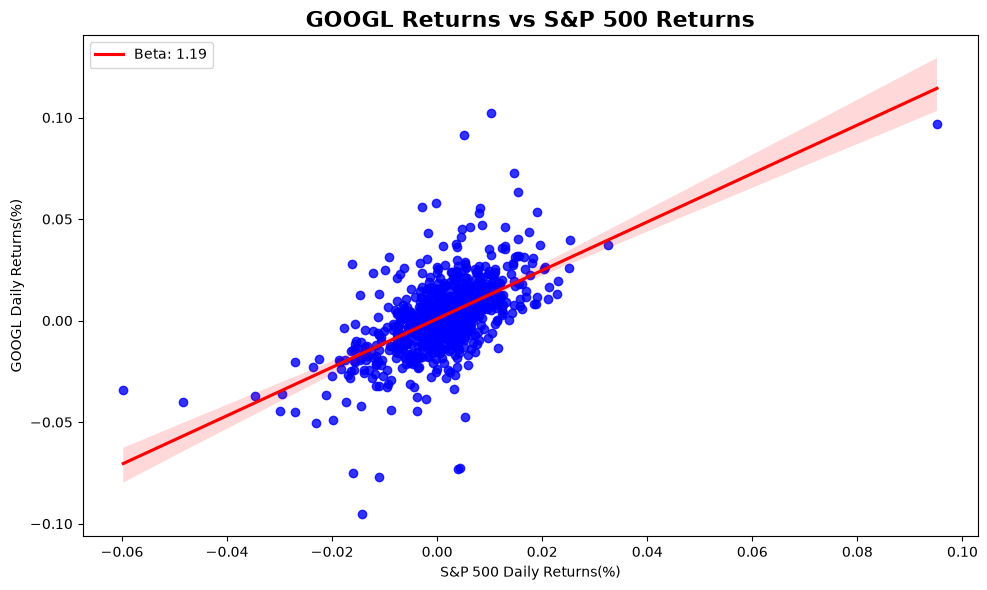

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='r_sp500', y='r_googl', 
            color='blue', data=returns_df, 
            line_kws={'color': 'red', 'label': f'Beta: {beta_googl:.2f}'})
plt.title('GOOGL Returns vs S&P 500 Returns',fontsize=16,fontweight='bold')
plt.xlabel('S&P 500 Daily Returns(%)')
plt.ylabel('GOOGL Daily Returns(%)')
plt.legend()
plt.tight_layout()

plt.savefig('googl_vs_sp500_returns.png', dpi=300)
plt.show()